# Load network
Build edges, nodes, and adjacency list from the input file. 

In [16]:
import networkx as nx
import numpy as np
import pandas as pd
import random

edges = np.loadtxt("train.csv", delimiter=",", dtype=int).tolist()
edges_test = np.loadtxt("test.csv", delimiter=",", dtype=int).tolist()

g_full = nx.Graph()
g_full.add_edges_from(edges)
non_edges = list(nx.non_edges(g_full))
node_to_row = {node: i for i, node in enumerate(g_full.nodes())}

print(f"# of nodes: {g_full.number_of_nodes()}")
print(f"# of undirected edges: {g_full.number_of_edges()}")
print(f"degrees = min: {np.min(list(dict(g_full.degree()).values()))}, max: {np.max(list(dict(g_full.degree()).values()))}, p75: {np.percentile(list(dict(g_full.degree()).values()), 75):.2f}, median: {np.median(list(dict(g_full.degree()).values())):.2f}")

# of nodes: 2485
# of undirected edges: 4969
degrees = min: 1, max: 167, p75: 5.00, median: 3.00


# Setup visualizations

In [17]:
import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

# Plotting the graph

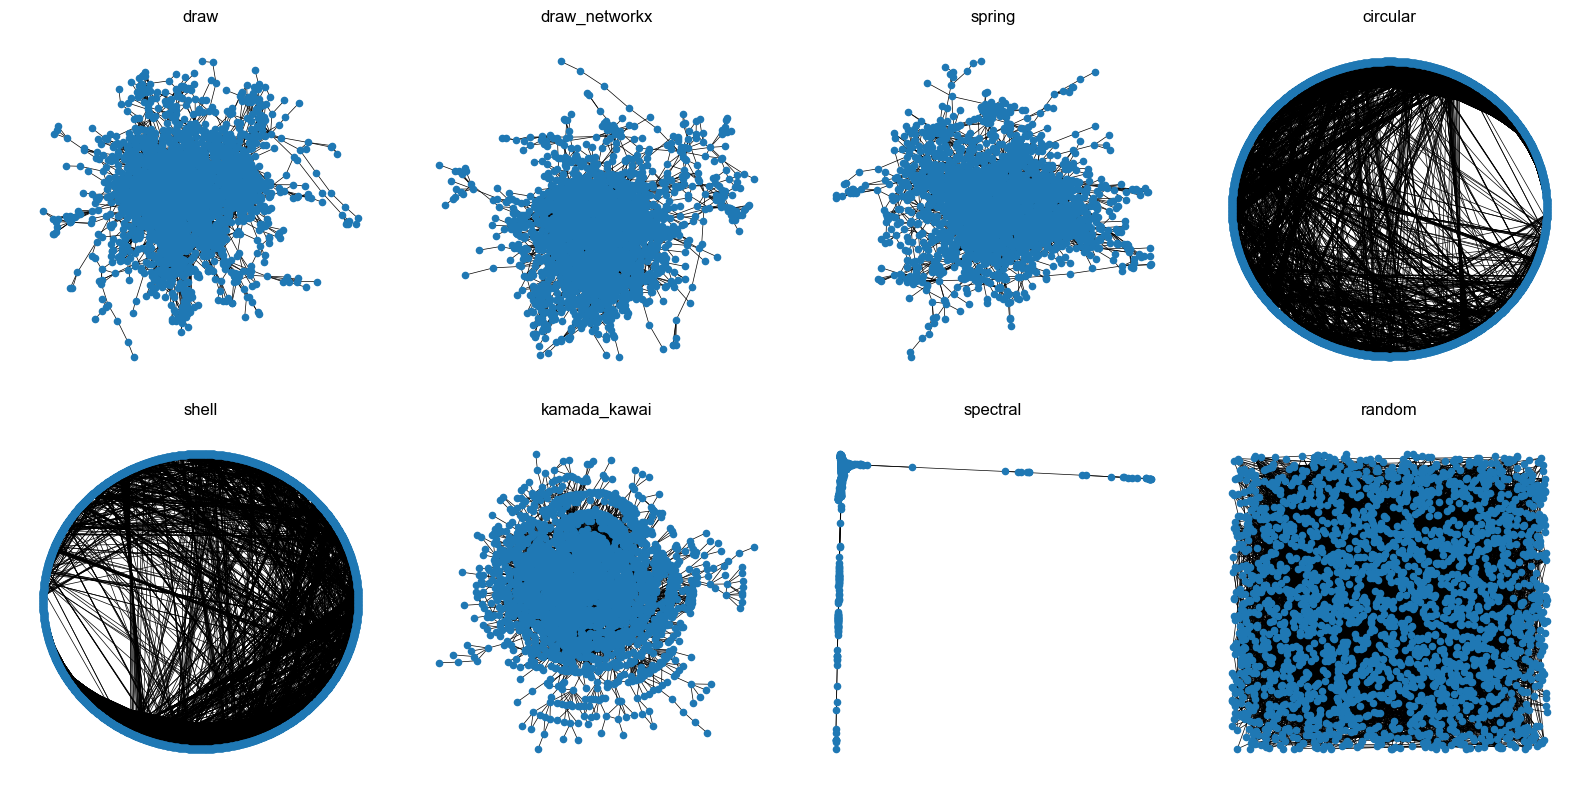

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

plots = [
    ("draw", lambda ax: nx.draw(g_full, ax=ax, node_size=20, width=0.5)),
    ("draw_networkx", lambda ax: nx.draw_networkx(g_full, ax=ax, node_size=20, width=0.5, with_labels=False)),
    ("spring", lambda ax: nx.draw_spring(g_full, ax=ax, node_size=20, width=0.5)),
    ("circular", lambda ax: nx.draw_circular(g_full, ax=ax, node_size=20, width=0.5)),
    ("shell", lambda ax: nx.draw_shell(g_full, ax=ax, node_size=20, width=0.5)),
    ("kamada_kawai", lambda ax: nx.draw_kamada_kawai(g_full, ax=ax, node_size=20, width=0.5)),
    ("spectral", lambda ax: nx.draw_spectral(g_full, ax=ax, node_size=20, width=0.5)),
    ("random", lambda ax: nx.draw_random(g_full, ax=ax, node_size=20, width=0.5)),
]

for ax, (title, plot_fn) in zip(axes, plots):
    plot_fn(ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Dataset split

The dataset is split into the following sets:

- **g_baseline** = 50% of the positive edges
- **Train set** = 30% of the positive edges + negative samples 
- **Test set** = 20% of the positive edges + negative samples

|  | Pos | Neg | Tot |
|---|---:|---:|---:|
| **g_baseline** | 2484 | 0 | 2484 |
| **Train** | 1491 | 1491 | 2982 |
| **Test** | 994 | 994 | 1988 |

Every method attends to *g_baseline* to learn/score from. Then they score the candidate edges in the *test* set. The *train* set is only used if training is needed (e.g., GCN).

In [18]:
from sklearn.model_selection import train_test_split

random.seed(42)

pos_baseline, pos_temp = train_test_split(edges, test_size=0.5, random_state=42)
pos_train, pos_val = train_test_split(pos_temp, test_size=0.4, random_state=42)

g_baseline = nx.Graph()
g_baseline.add_edges_from(pos_baseline)
g_baseline.add_nodes_from(g_full.nodes())

def add_negative_edges(X, Y):
    neg_edges = random.sample(non_edges, len(X))
    X = X + neg_edges
    Y = Y + [0] * len(neg_edges)
    return X, Y

X_train, Y_train = pos_train, [1] * len(pos_train)
X_train, Y_train = add_negative_edges(X_train, Y_train)

X_val, Y_val = pos_val, [1] * len(pos_val)
X_val, Y_val = add_negative_edges(X_val, Y_val)

print(f"Baseline graph: {g_baseline.number_of_edges()} edges")
print(f"Train: {len(X_train)} edges ({sum(Y_train)} positive, {len(Y_train) - sum(Y_train)} negative)")
print(f"Val: {len(X_val)} edges ({sum(Y_val)} positive, {len(Y_val) - sum(Y_val)} negative)")

Baseline graph: 2484 edges
Train: 2982 edges (1491 positive, 1491 negative)
Val: 1988 edges (994 positive, 994 negative)


# Evaluation

|                     | Predicted Positive | Predicted Negative |
|---------------------|:------------------:|:------------------:|
| **Actual Positive** |         TP         |         FN         |
| **Actual Negative** |         FP         |         TN         |

Definitions:
- **TP**: edge exists and is predicted  
- **FP**: edge *does not* exist but is predicted  
- **FN**: edge exists but is *not* predicted  
- **TN**: edge *does not* exist and is *not* predicted

To obtain **predictions** we convert raw scores to binary by selecting the top‑K edges as positive where K = number of true positives. Then, we calculate **accuracy** as:

$$
\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{FN} + \text{TN}}
$$

In [4]:
def binarize_scores(scores, top_k):
    """
    Converts a free-range score list into binary predictions by selecting the top-K edges as positive.
    """
    idx = np.argsort(scores)[-top_k:]
    Y_pred = np.zeros(len(scores))
    Y_pred[idx] = 1
    return Y_pred

In [5]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(scores, Y=Y_val):
    """
    Converts a free-range score list into binary predictions and computes accuracy.
    Selecting the top-K edges as positive, where K is the number of true positive edges.
    """
    top_k = Y.count(1)
    Y_pred = binarize_scores(scores, top_k)
    return accuracy_score(Y, Y_pred)

In [6]:
def display_test_results(scores: dict[tuple[int, int], float], top_k, name, save=False):
    """Display top-K edges based on a link prediction scoring measure and save them to a file."""
    items = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]

    edges_tuples, vals = zip(*items)
    edges_str = [f"{u},{v}" for u, v in edges_tuples]

    # plot up to top_k but not more than 20 for clarity
    top_plot = min(top_k, 20)
    plt.figure(figsize=(9, 4))
    plt.bar(range(top_plot), vals[:top_plot], color="tomato")
    plt.xticks(range(top_plot), edges_str[:top_plot], rotation=45)
    plt.grid(True, axis="y", alpha=0.3)
    plt.xlabel("Edge")
    plt.ylabel("Score")
    plt.title(f"Top {top_plot} edges by {name}")
    plt.tight_layout()
    plt.show()

    if save:
        with open("results.csv", "w") as f:
            f.write("\n".join(edges_str[:top_k]))
        print("Saved to ./results.csv")
    else: 
        print(f"Top {top_k} edges by {name}:")
        for pair, score in zip(edges_tuples, vals):
            print(f"Edge {pair}: {score:.4f}")

# Link prediction
The idea is to create a **scoring function** $\sigma(x, y)$ that measures the **proximity** between two nodes. 

The **top-k** scoring pairs of nodes are the candidate for having a new edge, if they are not already connected.

There are several *families* of scoring methods:

## Neighborhood-based (degree)
1. **Common Neighbors**: the more common neighbors the more similar
$$
\sigma(x, y) = |N(x) \cap N(y)|
$$

2. **Jaccard Similarity**: ...but normalizes by the total number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{|N(x) \cup N(y)|}
$$

3. **Cosine Similarity**: ...but normalizes by the geometric mean of the number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{\sqrt{|N(x)| \cdot |N(y)|}}
$$

4. **Adamic and Adar**: gives more weight to common neighbors with fewer connections
$$
\sigma(x, y) = \sum_{z \in N(x) \cap N(y)} \frac{1}{\log |N(z)|}
$$

5. **Preferential Attachment**: the more _(common or not)_ neighbors the more similar
$$
\sigma(x, y) = |N(x)| \cdot |N(y)|
$$

> To avoid having zero similarity, add the node *itself* to its neighbors.

## Random Walk-based (distance)
1. **Katz 1953**: the more short paths exist between them, the more similar
$$
\sigma(x, y) = \sum_{l=1}^{\infty} \beta^l |\text{paths}_{x, y}^{(l)}| = \sum \beta^l (A^l)_{xy}
$$

2. **Personalized PageRank**: the more likely to reach each other in a random walk, the more similar
$$
\sigma(x, y) = r_x(y) + r_y(x)
$$

## Community-based (clusters)
1. **Spectral Clustering**: the closer the eigenvector embedding of the nodes in the graph Laplacian, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

2. **Modularity Maximization**: the closer the eigenvector embedding of the node in the graph Modularity, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

## Embedding-based
1. **Node embeddings** (e.g. Node2Vec): the closer the node embeddings, the more similar
2. **Edge embeddings**: the closer the edge embeddings, the more similar
3. **Graph embeddings**: the closer the graph embeddings, the more similar
4. **Graph Neural Networks**: the closer the node embeddings learned by a GNN, the more similar

$$
\hat{A} = A + I
$$

$$
\hat{D} = \text{diag}\bigl(\sum_j \hat{A}_{ij}\bigr)
$$

$$
\tilde{A}=\hat{D}^{-1/2}\,\hat{A}\,\hat{D}^{-1/2}$$

$$d=\hat{A}{\bf1},\quad
X=\frac{d-\mu}{\sigma+\varepsilon}\quad (X\in\mathbb{R}^{N\times1})$$

Let linear layers be $\,\mathrm{Lin}_1(X)=XW_1+b_1,\;\mathrm{Lin}_2(H)=H W_2+b_2.$

$$H^{(1)}=\mathrm{Dropout}\big(\mathrm{ReLU}(\tilde{A}\,\mathrm{Lin}_1(X))\big)$$

$$Z=\tilde{A}\,\mathrm{Lin}_2(H^{(1)})\quad (Z\in\mathbb{R}^{N\times d_{emb}})$$

For a candidate edge $(u,v)$:

$$\ell_{uv}=z_u^\top z_v\qquad p_{uv}=\sigma(\ell_{uv})$$

(Here $\ell_{uv}$ are logits used with BCEWithLogitsLoss.)

## Method 1: Common Neighbors (neighborhood-based)

In [44]:
scores = np.zeros(len(X_val))
for i, candidate in enumerate(X_val):  # both positive and negative edges
    u, v = candidate
    scores[i] = len(list(nx.common_neighbors(g_baseline, u, v))) # in the graph with only positive edges
calculate_accuracy(scores)

0.9949698189134809

Saved to ./results.csv


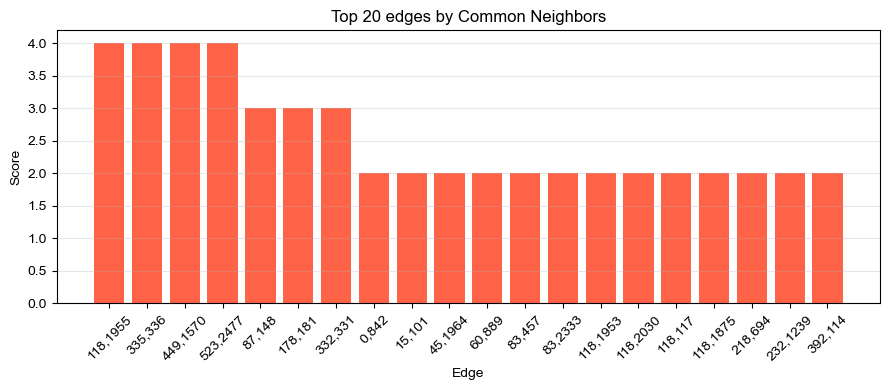

In [45]:
scores = {}
for i, candidate in enumerate(edges_test):  # both positive and negative edges
    u, v = candidate
    scores[(u,v)] = len(list(nx.common_neighbors(g_full, u, v))) # in the graph with only positive edges
display_test_results(scores, top_k=100, name="Common Neighbors", save=True)

# Method 2: Spectral Clustering (community-based)

In [46]:
from scipy.sparse.linalg import eigsh

EMB_SIZE = 10

L = nx.laplacian_matrix(g_full)
vals, vecs = eigsh(L, k=EMB_SIZE+1, which="SM")  # smallest K+1 smallest eigenvalues and their eigenvectors
M = vecs[:, 1:]  # skipping trivial first eigenvector

# lookup required: M rows are ordered like g_full.nodes() so not in node ID order
embed_candidate = lambda candidate: (M[node_to_row[candidate[0]]], M[node_to_row[candidate[1]]])

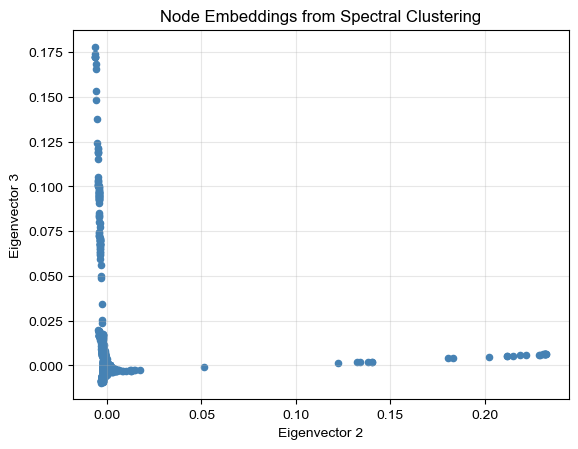

In [32]:
plt.figure()
plt.scatter(M[:, 0], M[:, 1], s=20, color="steelblue")
plt.title("Node Embeddings from Spectral Clustering")
plt.xlabel("Eigenvector 2")
plt.ylabel("Eigenvector 3")
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
from scipy.spatial.distance import cosine

scores = np.zeros(len(X_val))
for i, candidate in enumerate(X_val):  # both positive and negative edges
    u, v = embed_candidate(candidate)
    scores[i] = 1 - cosine(u, v)
calculate_accuracy(scores)

0.8933601609657947

Top 100 edges by Cosine Similarity:
Edge (1507, 1626): 1.0000
Edge (449, 1570): 1.0000
Edge (449, 185): 0.9999
Edge (449, 530): 0.9999
Edge (1145, 845): 0.9999
Edge (1462, 1548): 0.9999
Edge (2355, 1712): 0.9999
Edge (1825, 1994): 0.9998
Edge (881, 2156): 0.9998
Edge (335, 336): 0.9997
Edge (60, 889): 0.9997
Edge (1470, 2158): 0.9997
Edge (1495, 1517): 0.9997
Edge (1112, 2361): 0.9996
Edge (51, 1952): 0.9996
Edge (463, 1647): 0.9995
Edge (1213, 670): 0.9995
Edge (769, 1172): 0.9994
Edge (1076, 1336): 0.9994
Edge (232, 1239): 0.9993
Edge (2439, 1402): 0.9993
Edge (1114, 1505): 0.9993
Edge (1114, 1012): 0.9993
Edge (1706, 1717): 0.9992
Edge (79, 1291): 0.9992
Edge (1579, 1075): 0.9992
Edge (881, 1488): 0.9992
Edge (479, 1660): 0.9992
Edge (786, 2410): 0.9992
Edge (558, 614): 0.9992
Edge (102, 1760): 0.9992
Edge (505, 1547): 0.9992
Edge (505, 2462): 0.9992
Edge (1706, 1708): 0.9989
Edge (921, 1355): 0.9989
Edge (463, 102): 0.9989
Edge (316, 804): 0.9988
Edge (178, 181): 0.9988
Edge (613, 

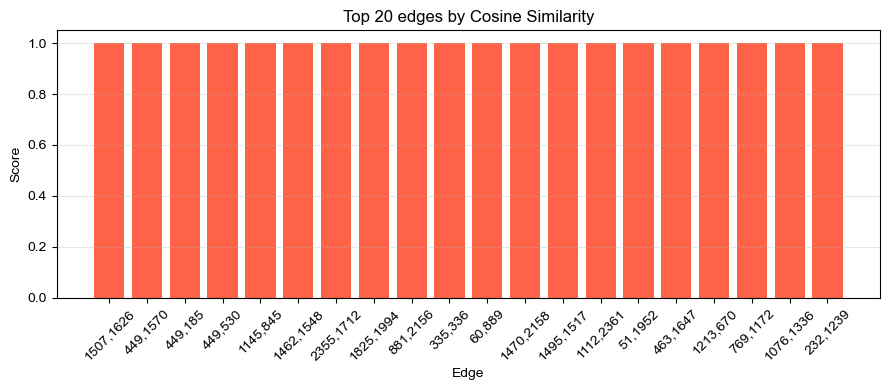

In [48]:
scores = {}
for i, candidate in enumerate(edges_test):  # both positive and negative edges
    u, v = candidate
    scores[(u,v)] = 1 - cosine(*embed_candidate(candidate))
display_test_results(scores, top_k=100, name="Cosine Similarity")

# Method 3: Graph Neural Network (embedding-based)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
generator = torch.Generator(device=device).manual_seed(42)

HID_SIZE = 64
EMB_SIZE = 12

class GCN(nn.Module):
    def __init__(self, graph, hidden_dim, out_dim):
        super().__init__()
        A = nx.to_numpy_array(graph, dtype=np.float32)
        A_hat = A + np.eye(A.shape[0], dtype=np.float32)    # adjacency matrix with self-loops

        deg = A_hat.sum(axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
        self.A_norm = torch.from_numpy(D_inv_sqrt @ A_hat @ D_inv_sqrt).float().to(device)

        X = (deg - deg.mean()) / (deg.std() + 1e-6)
        X = X.reshape(-1, 1)  # [N, 1]
        self.X = torch.from_numpy(X).float().to(device)

        self.W1 = nn.Linear(1, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, candidates):
        # layer 1 (input to hidden-dimensional)
        h = self.A_norm @ self.W1(self.X)
        h = F.relu(h)
        h = self.dropout(h)

        # layer 2 (hidden-dimensional to embedding-dimensional)
        emb = self.A_norm @ self.W2(h)

        u = torch.tensor([node_to_row[int(c[0])] for c in candidates], dtype=torch.long)
        v = torch.tensor([node_to_row[int(c[1])] for c in candidates], dtype=torch.long)

        logits = (emb[u] * emb[v]).sum(dim=1)  # dot product for link prediction
        return logits

model = GCN(g_full, hidden_dim=HID_SIZE, out_dim=EMB_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

model.load_state_dict(torch.load("gcn.pt"))

In [20]:
EPOCHS = 200
BATCH_SIZE = 128

train_batches = DataLoader(TensorDataset(
    torch.tensor(X_train),                       # [7950, 2]
    torch.tensor(Y_train, dtype=torch.float32),  # [8950]
), batch_size=BATCH_SIZE, shuffle=True, generator=generator)

val_batches = DataLoader(TensorDataset(
    torch.tensor(X_val),                        # [1988, 2]
    torch.tensor(Y_val, dtype=torch.float32),   # [2238]
), batch_size=BATCH_SIZE, generator=generator)

train_loss = []
val_loss = []
for epoch in tqdm(range(EPOCHS)):
    model.train()
    batch_losses = []
    for candidates, labels in train_batches:
        optimizer.zero_grad()
        logits = model(candidates)
        loss = criterion(logits, labels)
        batch_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    train_loss.append(np.average(batch_losses))   # batch average

    with torch.no_grad():
        model.eval()
        batch_losses = []
        for candidates, labels in val_batches:
            logits = model(candidates)
            loss = criterion(logits, labels)
            batch_losses.append(loss.item())
        val_loss.append(np.average(batch_losses))  # average over val batches

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Logits range: [{min(logits).item():.4f}, {max(logits).item():.4f}]")

torch.save(model.state_dict(), "gcn.pt")

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0, Train Loss: 0.6807, Val Loss: 0.6793, Logits range: [0.2371, 2.0211]
Epoch 20, Train Loss: 0.6084, Val Loss: 0.6110, Logits range: [-0.7142, 4.2296]
Epoch 40, Train Loss: 0.5997, Val Loss: 0.6030, Logits range: [-1.3114, 5.3978]
Epoch 60, Train Loss: 0.6019, Val Loss: 0.5988, Logits range: [-1.3788, 5.5790]
Epoch 80, Train Loss: 0.5964, Val Loss: 0.5952, Logits range: [-1.4176, 5.2583]
Epoch 100, Train Loss: 0.5865, Val Loss: 0.5902, Logits range: [-1.5251, 5.2224]
Epoch 120, Train Loss: 0.5849, Val Loss: 0.5851, Logits range: [-1.6187, 5.0426]
Epoch 140, Train Loss: 0.5817, Val Loss: 0.5805, Logits range: [-1.7283, 5.0703]
Epoch 160, Train Loss: 0.5790, Val Loss: 0.5777, Logits range: [-1.8067, 4.8987]
Epoch 180, Train Loss: 0.5742, Val Loss: 0.5757, Logits range: [-1.9128, 4.9612]


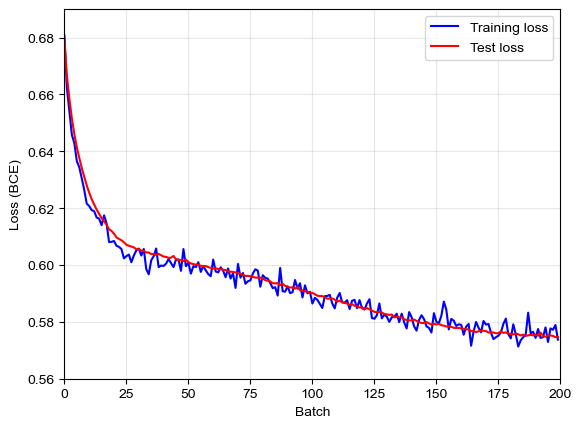

In [27]:
plt.figure()
plt.plot(train_loss, color="blue", label="Training loss")
plt.plot(val_loss, color="red", label="Test loss")
plt.legend()
plt.xlabel("Batch")
plt.ylabel("Loss (BCE)")
plt.grid(True, alpha=0.3)
plt.ylim(0.56, 0.69)
plt.xlim(0, EPOCHS)
plt.show()

In [35]:
with torch.no_grad():
    model.eval()
    scores = model(X_val).cpu().numpy()
calculate_accuracy(scores)

0.7263581488933601

Top 100 edges by GCN:
Edge (118, 1955): 10.2221
Edge (0, 842): 6.1539
Edge (118, 1875): 4.8476
Edge (118, 1953): 3.2181
Edge (118, 2030): 3.2181
Edge (1294, 2312): 3.0610
Edge (83, 280): 2.9900
Edge (128, 166): 2.7251
Edge (558, 614): 2.7110
Edge (363, 571): 2.4953
Edge (89, 1366): 2.2690
Edge (881, 2156): 2.2010
Edge (197, 1564): 2.1861
Edge (659, 2061): 2.1744
Edge (118, 117): 2.1111
Edge (931, 1250): 2.0510
Edge (15, 101): 1.9483
Edge (85, 2009): 1.8815
Edge (1245, 2038): 1.8799
Edge (523, 2477): 1.8242
Edge (218, 694): 1.7299
Edge (196, 725): 1.7252
Edge (50, 1786): 1.7091
Edge (144, 1932): 1.6582
Edge (116, 1959): 1.6228
Edge (1153, 761): 1.6179
Edge (643, 1114): 1.6155
Edge (816, 1519): 1.5807
Edge (352, 2439): 1.5441
Edge (47, 2278): 1.4647
Edge (48, 1366): 1.4641
Edge (523, 690): 1.4309
Edge (971, 2092): 1.3928
Edge (1580, 1746): 1.3718
Edge (1002, 1955): 1.3669
Edge (178, 181): 1.3409
Edge (743, 1431): 1.3215
Edge (505, 648): 1.3005
Edge (582, 1538): 1.2950
Edge (29, 1409): 1.

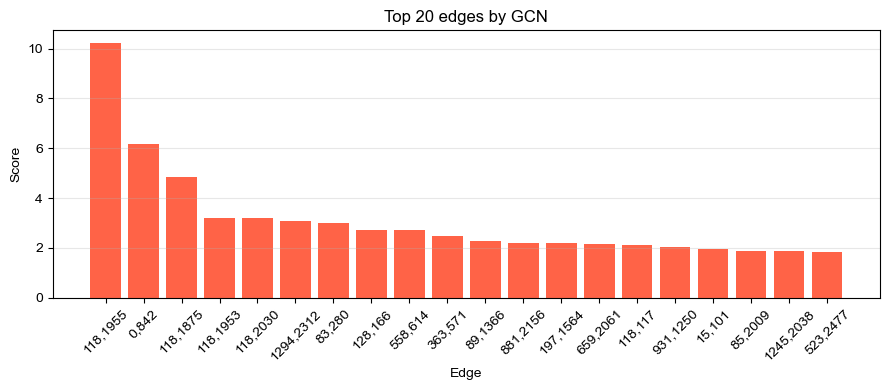

In [26]:
with torch.no_grad():
    model.eval()
    scores = {
        tuple(edge): float(score)
        for edge, score in zip(edges_test, model(torch.tensor(edges_test)).cpu().numpy().reshape(-1))
    }
    display_test_results(scores, top_k=100, name="GCN")